In [45]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from warnings import filterwarnings
filterwarnings("ignore")

In [2]:
df = pd.read_csv(r'D:\Data Analytics\DA_python_projects\netflix_analysis\dataset\clean_dataset.csv' )
df.head(5)

,show_id,category,title,director,cast,country,date_added,rating,duration,genres,year_added,month_added,duration_value,duration_unit,duration_min,seasons,primary_country,primary_genre
0,s1,TV Show,3%,Unknown,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,2020-08-14,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",2020,8,4,Seasons,NaN,4.0,Brazil,International TV Shows
1,s2,Movie,07:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,2016-12-23,TV-MA,93 min,"Dramas, International Movies",2016,12,93,min,93.0,NaN,Mexico,Dramas
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,2018-12-20,R,78 min,"Horror Movies, International Movies",2018,12,78,min,78.0,NaN,Singapore,Horror Movies
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,2017-11-16,PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi...",2017,11,80,min,80.0,NaN,United States,Action & Adventure
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,2020-01-01,PG-13,123 min,Dramas,2020,1,123,min,123.0,NaN,United States,Dramas


In [3]:
df.describe()

,year_added,month_added,duration_value,duration_min,seasons
count,7777.000000,7777.000000,7777.000000,5377.000000,2400.000000
mean,2018.493378,6.783850,69.204706,99.307978,1.760833
std,1.388144,3.591608,50.931983,28.530881,1.560603
min,2008.000000,1.000000,1.000000,3.000000,1.000000
25%,2018.000000,4.000000,2.000000,86.000000,1.000000
50%,2019.000000,7.000000,88.000000,98.000000,1.000000
75%,2020.000000,10.000000,106.000000,114.000000,2.000000
max,2021.000000,12.000000,312.000000,312.000000,16.000000


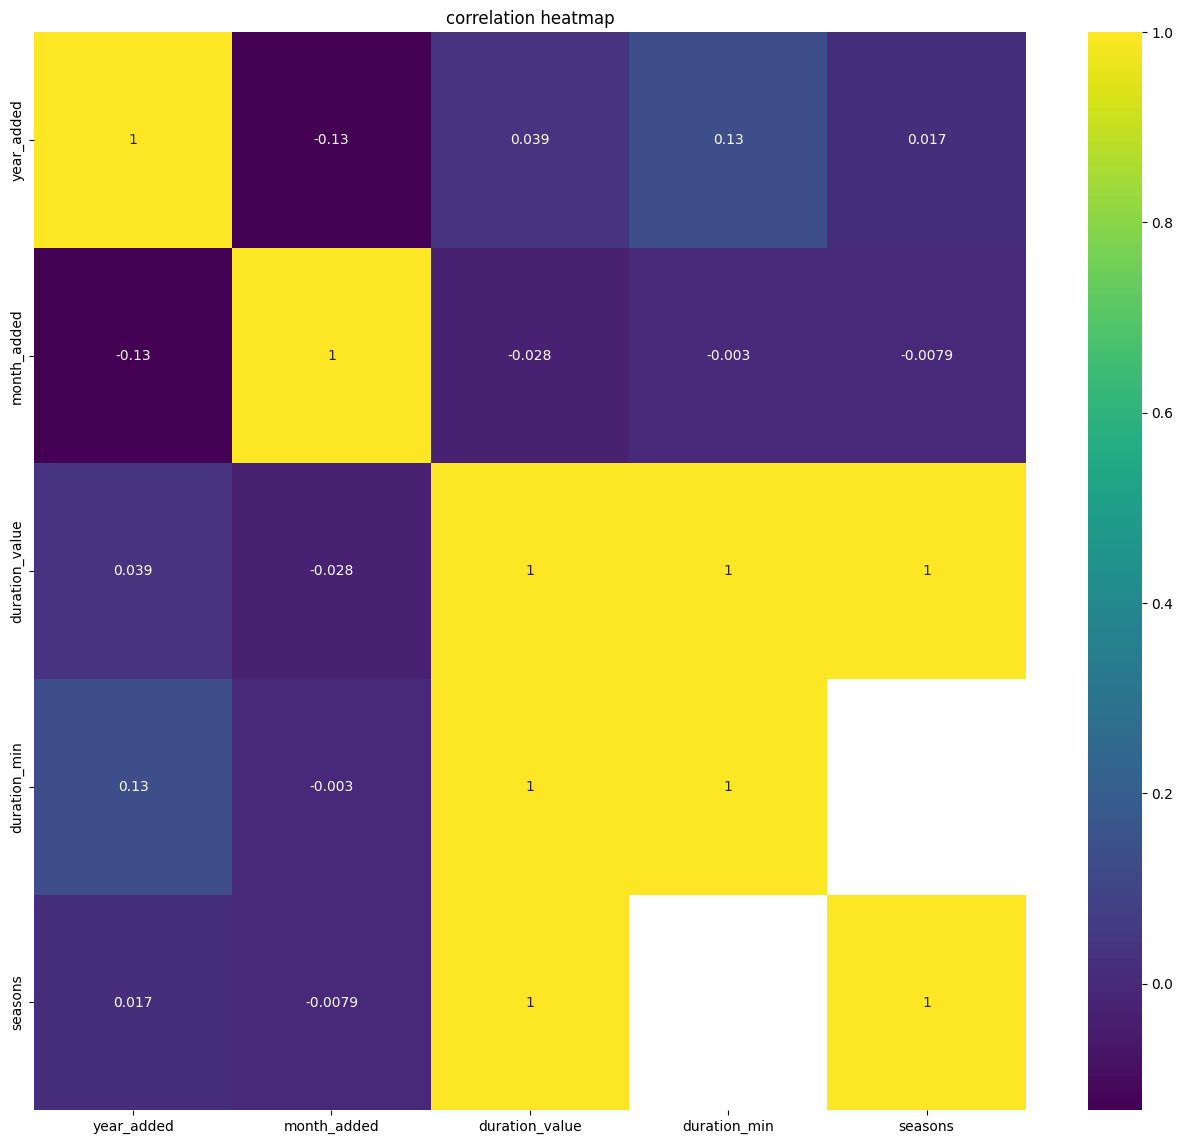

In [6]:
drop_col = df.drop(columns=['show_id'])
numeric_cols = drop_col.select_dtypes(include=['int64','float32','int32','float64'])
plt.figure(figsize=(16,14))
sns.heatmap(numeric_cols.corr() , annot=True ,cmap="viridis" )
plt.title("correlation heatmap")
plt.show()

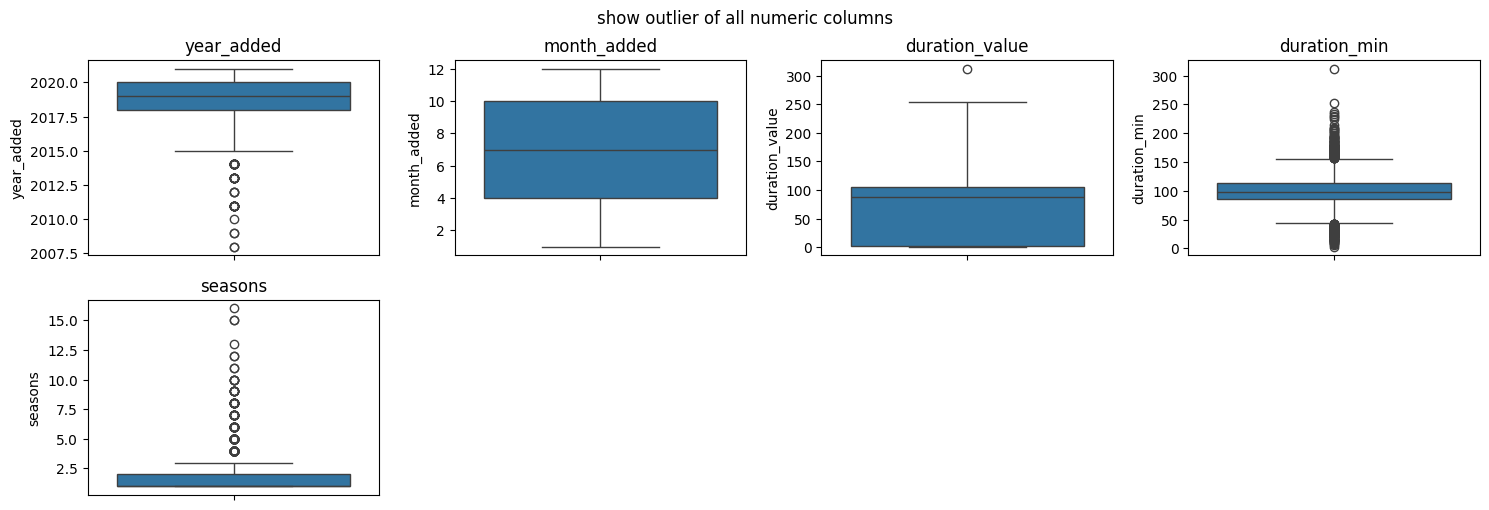

In [7]:
# numerical_cols = df.select_dtypes(include=["float64", "int64"]).columns
plt.figure(figsize=(15, 10))
for i, col in enumerate(numeric_cols):
    plt.subplot(4, 4, i + 1) # adjust the number of rows and columns as needed
    sns.boxplot(df[col])
    plt.title(col)
plt.suptitle('show outlier of all numeric columns')
plt.tight_layout()
plt.show()

In [9]:
# how many outlier in column??
def detect_outliers(df , col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers_iqr = ((df[col] < lower_bound) | (df[col] > upper_bound))
    print(f"IQR method identified {outliers_iqr.sum()} outliers in {col}")
    return outliers_iqr

outlier_col = ['year_added' , 'month_added' , 'duration_value' , 'duration_min' , 'seasons']

for col in outlier_col:
    detect_outliers(df ,col)

IQR method identified 57 outliers in year_added
IQR method identified 0 outliers in month_added
IQR method identified 1 outliers in duration_value
IQR method identified 337 outliers in duration_min
IQR method identified 231 outliers in seasons


# 📊KPI

In [16]:
total_genere = df['primary_genre'].nunique()
print(f'total genere avalilable {total_genere}')

avg_duration = df['duration_min'].mean()
print(f'avg duration min {avg_duration.round(2)} min')

total_movies = (df["category"] == "Movie").sum()
print(f"Total Movies: {total_movies:,}")

total_tv_shows = (df["category"] == "TV Show").sum()
print(f"Total Movies: {total_tv_shows:,}")

total genere avalilable 36
avg duration min 99.31 min
Total Movies: 5,377
Total Movies: 2,400


# 📊analysis

**top 10 higest season tv shows**

In [24]:
tv_shows = df[df["category"] == "TV Show"].copy()

# Select relevant columns and sort by number of seasons (highest first)
top_10_seasons = (
    tv_shows[["title", "seasons", "primary_country", "primary_genre", "rating"]]
    .dropna(subset=["seasons"])
    .sort_values(by="seasons", ascending=False)
    .head(10)
    .reset_index(drop=True)
)

# Display the result
display(top_10_seasons)

,title,seasons,primary_country,primary_genre,rating
0,Grey's Anatomy,16.0,United States,Romantic TV Shows,TV-14
1,Supernatural,15.0,United States,Classic & Cult TV,TV-14
2,NCIS,15.0,United States,Crime TV Shows,TV-14
3,COMEDIANS of the world,13.0,United States,Stand-Up Comedy & Talk Shows,TV-MA
4,Trailer Park Boys,12.0,Canada,Classic & Cult TV,TV-MA
5,Criminal Minds,12.0,United States,Crime TV Shows,TV-14
6,Cheers,11.0,United States,Classic & Cult TV,TV-PG
7,Heartland,11.0,Canada,TV Dramas,TV-14
8,LEGO Ninjago: Masters of Spinjitzu,10.0,Denmark,Kids' TV,TV-Y7
9,Stargate SG-1,10.0,United States,Classic & Cult TV,TV-MA


**top 10 movies with higest duration_min**

In [41]:
tv_shows = df[df["category"] == "Movie"].copy()

# Select relevant columns and sort by number of seasons (highest first)
top_10_movie_duration = (
    tv_shows[["title", "duration_min","primary_country", "primary_genre", "rating"]]
    .dropna(subset=["duration_min"])
    .sort_values(by="duration_min", ascending=False)
    .head(10)
    .reset_index(drop=True)
)

# Display the result
display(top_10_movie_duration)

,title,duration_min,primary_country,primary_genre,rating
0,Black Mirror: Bandersnatch,312.0,United States,Dramas,TV-MA
1,The School of Mischief,253.0,Egypt,Comedies,TV-14
2,No Longer kids,237.0,Egypt,Comedies,TV-14
3,Lock Your Girls In,233.0,Unknown,Comedies,TV-PG
4,Raya and Sakina,230.0,Unknown,Comedies,TV-14
5,Sangam,228.0,India,Classic Movies,TV-14
6,Lagaan,224.0,India,Dramas,PG
7,Jodhaa Akbar,214.0,India,Action & Adventure,TV-14
8,Kabhi Khushi Kabhie Gham,209.0,India,Dramas,TV-14
9,The Irishman,209.0,United States,Dramas,R


**top 10 director who make higest no of tv show**

In [27]:
# Filter only TV Shows
tv_shows = df[df["category"] == "TV Show"]

# Top 10 directors by number of TV Shows (excluding "Unknown")
top_10_directors = (
    tv_shows[tv_shows["director"] != "Unknown"]
    ["director"]
    .value_counts()
    .head(10).reset_index()
)

print("Top 10 Directors with Highest Number of TV Shows:\n")
display(top_10_directors)

# Optional: also show the count including "Unknown"
print("\n--- Including 'Unknown' ---")
display(tv_shows["director"].value_counts().head(10).reset_index())

Top 10 Directors with Highest Number of TV Shows:



,director,count
0,Alastair Fothergill,3
1,Stan Lathan,2
2,Shin Won-ho,2
3,Iginio Straffi,2
4,Ken Burns,2
5,Rob Seidenglanz,2
6,Nizar Shafi,1
7,"Steven Bognar, Julia Reichert",1
8,Carla Barros,1
9,Kazuya Murata,1



--- Including 'Unknown' ---


,director,count
0,Unknown,2215
1,Alastair Fothergill,3
2,Stan Lathan,2
3,Shin Won-ho,2
4,Iginio Straffi,2
5,Ken Burns,2
6,Rob Seidenglanz,2
7,Nizar Shafi,1
8,"Steven Bognar, Julia Reichert",1
9,Carla Barros,1


**top 10 director who make higest no of movie**

In [29]:
# Filter only TV Shows
tv_shows = df[df["category"] == "Movie"]

# Top 10 directors by number of TV Shows (excluding "Unknown")
top_10_directors = (
    tv_shows[tv_shows["director"] != "Unknown"]
    ["director"]
    .value_counts()
    .head(10).reset_index()
)

print("Top 10 Directors with Highest Number of movies:\n")
display(top_10_directors)

# Optional: also show the count including "Unknown"
print("\n--- Including 'Unknown' ---")
display(tv_shows["director"].value_counts().head(10).reset_index())

Top 10 Directors with Highest Number of movies:



,director,count
0,"Raúl Campos, Jan Suter",18
1,Marcus Raboy,15
2,Jay Karas,14
3,Cathy Garcia-Molina,13
4,Youssef Chahine,12
5,Martin Scorsese,12
6,Jay Chapman,12
7,Steven Spielberg,10
8,David Dhawan,9
9,Kunle Afolayan,8



--- Including 'Unknown' ---


,director,count
0,Unknown,163
1,"Raúl Campos, Jan Suter",18
2,Marcus Raboy,15
3,Jay Karas,14
4,Cathy Garcia-Molina,13
5,Youssef Chahine,12
6,Jay Chapman,12
7,Martin Scorsese,12
8,Steven Spielberg,10
9,David Dhawan,9


**yearly total reaslease tv shows and movies**

Yearly Total Releases (Movies vs TV Shows):



category,Movie,TV Show
year_added,,
2008,1,1
2009,2,0
2010,1,0
2011,13,0
2012,3,0
2013,6,5
2014,19,6
2015,58,30
2016,258,185


<Figure size 1200x600 with 0 Axes>

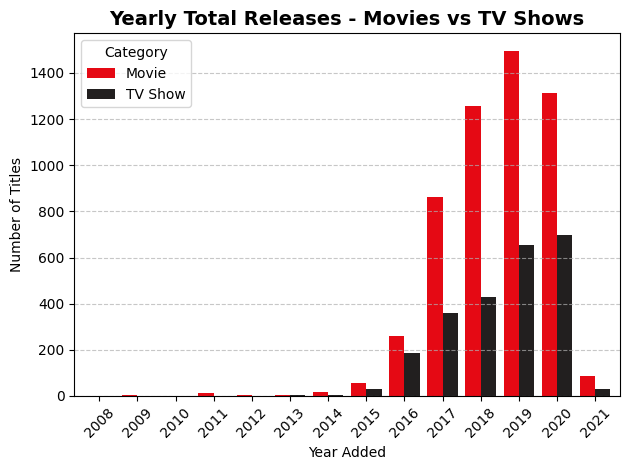

In [31]:
# Yearly count of Movies and TV Shows (separate)
yearly_counts = (
    df.groupby(["year_added", "category"])
    .size()
    .unstack(fill_value=0)
    .sort_index()
)

print("Yearly Total Releases (Movies vs TV Shows):\n")
display(yearly_counts)

# Optional: Visualization
plt.figure(figsize=(12, 6))
yearly_counts.plot(kind="bar", width=0.8, color=["#E50914", "#221F1F"])
plt.title("Yearly Total Releases - Movies vs TV Shows", fontsize=14, fontweight="bold")
plt.xlabel("Year Added")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45)
plt.legend(title="Category")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

**country wise realese movie**

Country-wise Movie Releases:

             Country  Number of Movies
       United States              2100
               India               883
      United Kingdom               341
             Unknown               230
              Canada               175
              France               137
               Spain               119
               Egypt                93
              Mexico                79
              Turkey                78
               Japan                75
         Philippines                74
           Hong Kong                74
           Indonesia                74
             Germany                68
             Nigeria                63
           Australia                56
              Brazil                52
           Argentina                50
               China                48
               Italy                42
         South Korea                42
            Thailand                39
        South Africa              

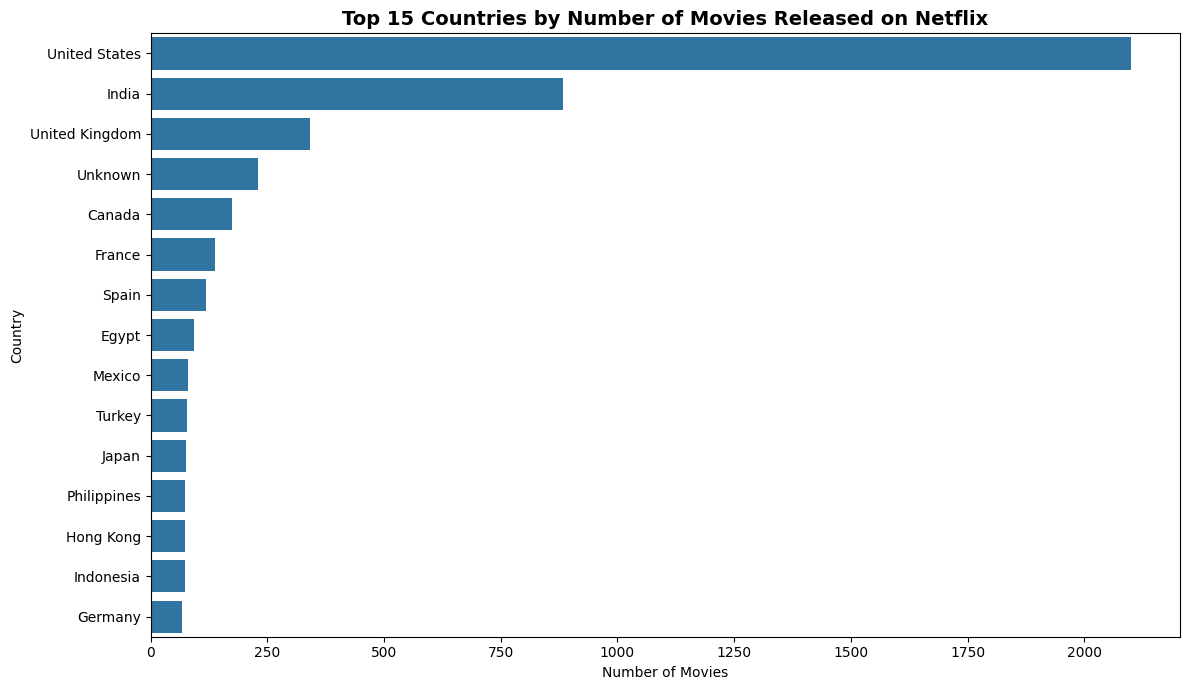

In [39]:
# Filter only Movies
movies = df[df['category'] == 'Movie']

# Country-wise count of Movies
country_movie_count = (
    movies['primary_country']
    .value_counts()
    .reset_index()
)
country_movie_count.columns = ['Country', 'Number of Movies']

# Display the result
print("Country-wise Movie Releases:\n")
print(country_movie_count.to_string(index=False))

# # Optional: Top 15 countries bar plot
plt.figure(figsize=(12, 7))
sns.barplot(
    data=country_movie_count.head(15),
    x='Number of Movies',
    y='Country'
)
plt.title('Top 15 Countries by Number of Movies Released on Netflix', fontsize=14, fontweight='bold')
plt.xlabel('Number of Movies')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

**top 10 primary_genre that have higest no of tv show and movies**

Top 10 Primary Genres by Number of Movies:


,Primary Genre,Number of Movies
0,Dramas,1384
1,Comedies,1074
2,Documentaries,751
3,Action & Adventure,721
4,Children & Family Movies,502
5,Stand-Up Comedy,321
6,Horror Movies,244
7,International Movies,114
8,Classic Movies,77
9,Movies,56



Top 10 Primary Genres by Number of TV Shows:


,Primary Genre,Number of TV Shows
0,International TV Shows,689
1,Crime TV Shows,369
2,Kids' TV,357
3,British TV Shows,231
4,Docuseries,193
5,Anime Series,147
6,TV Comedies,109
7,Reality TV,102
8,TV Dramas,62
9,TV Action & Adventure,36


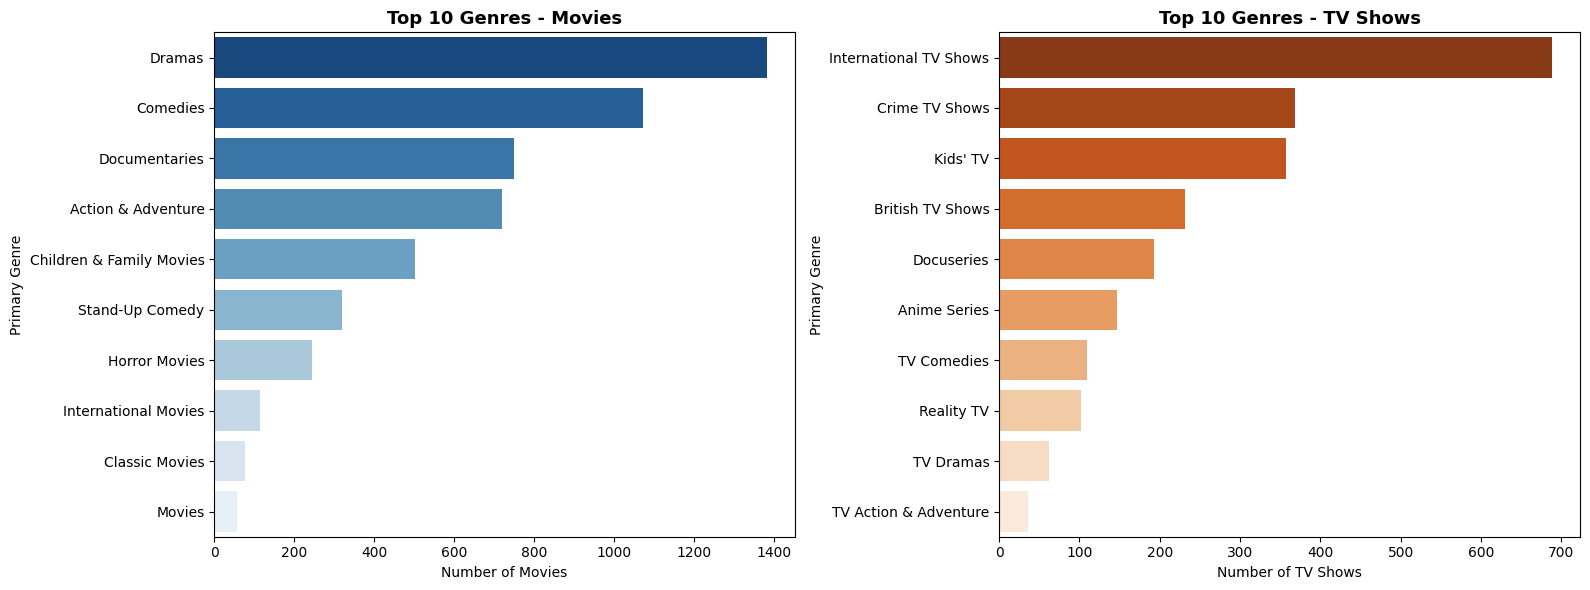

In [46]:
# ==============================
# Top 10 Primary Genres - Movies
# ==============================
top_10_movie_genres = (
    df[df['category'] == 'Movie']['primary_genre']
    .value_counts()
    .head(10)
    .reset_index()
)
top_10_movie_genres.columns = ['Primary Genre', 'Number of Movies']

print("Top 10 Primary Genres by Number of Movies:")
display(top_10_movie_genres)

# ==============================
# Top 10 Primary Genres - TV Shows
# ==============================
top_10_tv_genres = (
    df[df['category'] == 'TV Show']['primary_genre']
    .value_counts()
    .head(10)
    .reset_index()
)
top_10_tv_genres.columns = ['Primary Genre', 'Number of TV Shows']

print("\nTop 10 Primary Genres by Number of TV Shows:")
display(top_10_tv_genres)

import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Movies
sns.barplot(data=top_10_movie_genres, x='Number of Movies', y='Primary Genre', 
            palette='Blues_r', ax=axes[0])
axes[0].set_title('Top 10 Genres - Movies', fontsize=13, fontweight='bold')

# TV Shows
sns.barplot(data=top_10_tv_genres, x='Number of TV Shows', y='Primary Genre', 
            palette='Oranges_r', ax=axes[1])
axes[1].set_title('Top 10 Genres - TV Shows', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()